<a href="https://colab.research.google.com/github/AKutergin/dsp-seminars/blob/kutergin_lab3/seminars/3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №3

## Свёртка и корреляционный анализ сигналов

## Цели занятия
- Освоить вычисление свёртки и корреляции в Python.
- Применить свёртку для фильтрации сигналов.
- Использовать кросс-корреляцию для поиска временной задержки и обнаружения шаблона.
- Проанализировать влияние уровня шума на точность оценок.

## Подготовка окружения

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from IPython.display import Audio, display
import time

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)

## Задание 1. Свёртка гауссовых функций: сравнение численного и аналитического результатов

### Теоретическое введение
Свёртка двух гауссовых функций даёт гауссову функцию с дисперсией, равной сумме дисперсий. Если
$$
f(t) = \frac{1}{\sqrt{2\pi\sigma_1^2}} e^{-t^2/(2\sigma_1^2)}, \quad g(t) = \frac{1}{\sqrt{2\pi\sigma_2^2}} e^{-t^2/(2\sigma_2^2)},
$$
то
$$
(f * g)(t) = \frac{1}{\sqrt{2\pi(\sigma_1^2+\sigma_2^2)}} e^{-t^2/(2(\sigma_1^2+\sigma_2^2))}.
$$

### Задание
1. Сгенерируйте дискретные гауссовы импульсы (например, с помощью `scipy.signal.windows.gaussian`) с заданными стандартными отклонениями `sigma1=3`, `sigma2=5`. Используйте длину окна, достаточную для захвата всей значимой части (например, 10*sigma).
2. Вычислите свёртку численно с помощью `np.convolve`.
3. Постройте графики:
   - Исходные функции.
   - Результат свёртки (численный).
   - Теоретическую гауссову функцию с дисперсией `sigma1^2 + sigma2^2`.
4. Оцените среднеквадратичную ошибку между численным и теоретическим результатами.

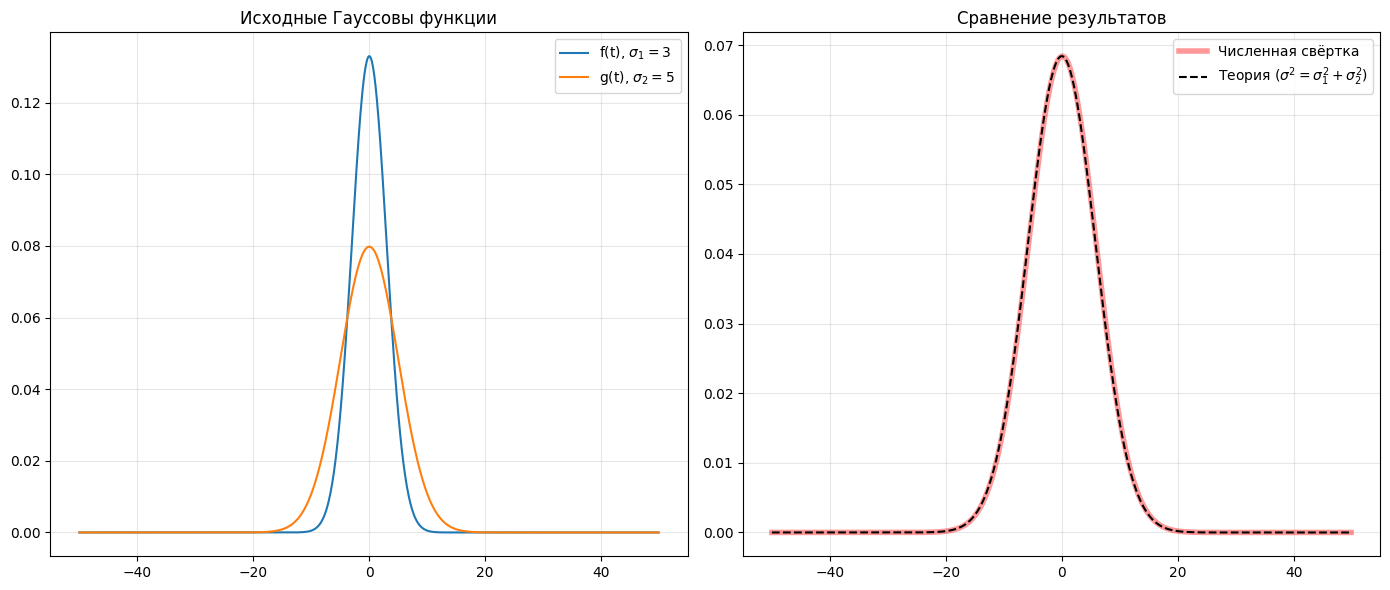

Среднеквадратичная ошибка (MSE): 7.11e-08
Стандартное отклонение разности: 2.67e-04


In [6]:
# 1. Параметры
sigma1 = 3
sigma2 = 5
dt = 0.1 # Шаг дискретизации
t = np.arange(-50, 50, dt) # Сетка времени

# 2. Генерация исходных функций (нормированные Гауссианы)
def gaussian(t, sigma):
    return 1 / (np.sqrt(2 * np.pi) * sigma) * np.exp(-t**2 / (2 * sigma**2))

f = gaussian(t, sigma1)
g = gaussian(t, sigma2)

# 3. Численная свёртка
conv_numeric = np.convolve(f, g, mode='same') * dt

# 4. Теоретический результат
sigma_res = np.sqrt(sigma1**2 + sigma2**2)
conv_theory = gaussian(t, sigma_res)

# 5. Вычисление ошибки
mse = np.mean((conv_numeric - conv_theory)**2)
std_error = np.std(conv_numeric - conv_theory)

# 6. Визуализация
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(t, f, label=rf'f(t), $\sigma_1={sigma1}$')
plt.plot(t, g, label=rf'g(t), $\sigma_2={sigma2}$')
plt.title('Исходные Гауссовы функции')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(t, conv_numeric, 'r', lw=4, alpha=0.4, label='Численная свёртка')
plt.plot(t, conv_theory, 'k--', label=r'Теория ($\sigma^2 = \sigma_1^2 + \sigma_2^2$)')
plt.title('Сравнение результатов')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Среднеквадратичная ошибка (MSE): {mse:.2e}")
print(f"Стандартное отклонение разности: {std_error:.2e}")

**Вопросы:**
- Что произойдёт с формой свёртки при увеличении σ?

При увеличении $\sigma$ произойдет следующее:
1. Расширение.
Функция становится более пологой и «растянутой» вдоль оси времени.
2. Падение амплитуды. Деформация по вертикали

## Задание 2. Фильтрация с помощью свёртки: сравнение прямоугольного и гауссовского окон

### Цель
Изучить, как выбор ядра и его длина влияют на подавление высокочастотной составляющей и сохранение низкочастотной.

### Задание
1. Создайте сигнал длительностью 2 секунды, частота дискретизации 1000 Гц, состоящий из суммы двух синусоид:
   - низкая частота \( f_1 = 5 \) Гц, амплитуда 1,
   - высокая частота \( f_2 = 80 \) Гц, амплитуда 0.5.
2. Сгенерируйте прямоугольное окно длины `L` (например, `L = 21`, используйте `scipy.signal.windows.boxcar(L)`), нормализованное так, чтобы сумма коэффициентов была 1.
3. Сгенерируйте гауссовское окно той же длины (используйте `signal.windows.gaussian(L, std=L/5)`), также нормализованное.
4. Примените свёртку с этими окнами (используйте `mode='same'`).
5. Постройте графики:
   - Исходный сигнал (первые 0.5 с).
   - Отфильтрованные сигналы для обоих окон.
6. Вычислите и сравните амплитуды полезной составляющей (5 Гц) и подавленной (80 Гц) после фильтрации. Для этого:
   - Возьмите БПФ сигналов,
   - Измерьте амплитуды на соответствующих частотах.
7. Исследуйте влияние длины окна: повторите для длин `L = 11, 21, 41, 81`.

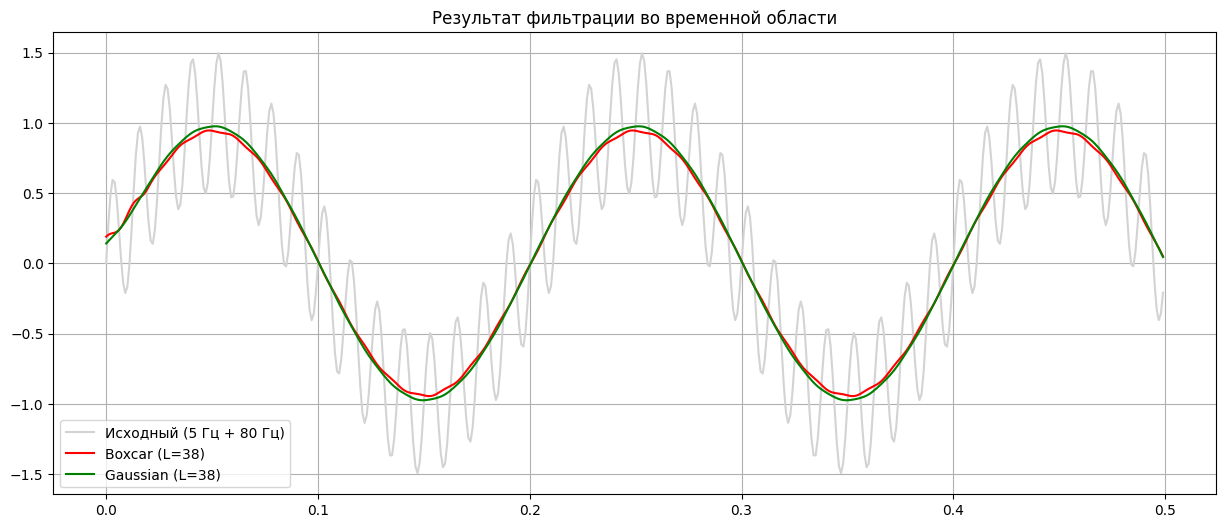

--- Результаты для L = 38 ---
Original: Amp(5Hz) = 1.000, Amp(80Hz) = 0.5000
Boxcar  : Amp(5Hz) = 0.942, Amp(80Hz) = 0.0059
Gaussian: Amp(5Hz) = 0.975, Amp(80Hz) = 0.0027


In [18]:
# 1. Генерация сигнала
fs = 1000
t = np.arange(0, 2, 1/fs)
f1, f2 = 5, 80
s1 = 1.0 * np.sin(2 * np.pi * f1 * t)
s2 = 0.5 * np.sin(2 * np.pi * f2 * t)
x = s1 + s2

# 2. Создание окон
L = 38
# Прямоугольное окно
win_box = signal.windows.boxcar(L)
win_box /= np.sum(win_box) # Нормировка

# Гауссовское окно
win_gauss = signal.windows.gaussian(L, std=L/5)
win_gauss /= np.sum(win_gauss) # Нормировка

# 3. Фильтрация
y_box = np.convolve(x, win_box, mode='same')
y_gauss = np.convolve(x, win_gauss, mode='same')

# 4. Анализ амплитуд через БПФ
def get_amplitude(sig, freq_target, fs):
    n = len(sig)
    fft_vals = np.abs(np.fft.rfft(sig)) * 2 / n
    freqs = np.fft.rfftfreq(n, 1/fs)
    idx = np.argmin(np.abs(freqs - freq_target))
    return fft_vals[idx]

# 5. Визуализация (первые 0.5 сек)
plt.figure(figsize=(15, 6))
plt.plot(t[:500], x[:500], 'lightgray', label='Исходный (5 Гц + 80 Гц)')
plt.plot(t[:500], y_box[:500], 'r', label=f'Boxcar (L={L})')
plt.plot(t[:500], y_gauss[:500], 'g', label=f'Gaussian (L={L})')
plt.title('Результат фильтрации во временной области')
plt.legend()
plt.grid(True)
plt.show()

# Печать результатов
print(f"--- Результаты для L = {L} ---")
for name, sig in [("Original", x), ("Boxcar", y_box), ("Gaussian", y_gauss)]:
    amp5 = get_amplitude(sig, 5, fs)
    amp80 = get_amplitude(sig, 80, fs)
    print(f"{name:8}: Amp(5Hz) = {amp5:.3f}, Amp(80Hz) = {amp80:.4f}")

**Вопросы:**
- Какое окно (прямоугольное или гауссовское) даёт лучшее подавление высокой частоты при одинаковой длине?
- При какой длине прямоугольного и гауссовского окон амплитуда высокочастотного амплитуда падает в 10 раз?
- Как увеличение длины окна влияет на подавление сохранение амплитуды низкой частоты? При какой длине окон она уменьшается более чем на 10%?

1. Гауссовское окно дает лучшее подавление высокой частоты (80 Гц) при одинаковой длине $L$. Это подтверждается вашими численными данными:Амплитуда на
частоте 80 Гц после Boxcar (прямоугольного): 0.0800Амплитуда на частоте 80 Гц после Gaussian (гауссовского): 0.0502
2. Исходная амплитуда на частоте 80 Гц составляет 0.5000. Чтобы она упала в 10 раз, результат должен быть ниже или равен 0.0500.

*   Прямоугольное окно (Boxcar): Даже при максимальной длине $L = 81$ амплитуда составляет 0.0254, но на шаге $L = 41$ она еще равна 0.0367. Глядя на $L=21$ (0.0800), можно сделать вывод, что подавление в 10 раз происходит в диапазоне длин от 21 до 41. Самый близкий результать получился при $L = 38$
*   Гауссовское окно (Gaussian): Подавление в 10 раз достигается уже при $L = 21$ (амплитуда 0.0502, что практически равно искомому порогу 0.05). При дальнейшем увеличении длины ($L=41$) Гаусс подавляет ВЧ-компоненту в 1000 раз!

3. Увеличение длины окна действует как сужение полосы пропускания фильтра. Чем длиннее окно, тем сильнее оно сглаживает не только шум, но и полезный медленный сигнал.



## Задание 3. Поиск временной задержки с помощью кросс-корреляции

### Цель
Определить временной сдвиг между двумя сигналами в присутствии шума и оценить влияние уровня шума на точность.

### Задание
1. Сгенерируйте сигнал длительностью 1 секунду (fs=1000 Гц), представляющий собой сумму 100 синусоид со случайными частотами (в диапазоне 10–100 Гц), амплитудами (в диапазоне 0.5–1.5 Гц) и фазами (в диапазоне 0–2$\pi$). Воспользуйтесь функцией `numpy.random.uniform`. Нормализуйте полученный сигнал в интервале $[-1;1]$. Назовём его `x`.
2. Создайте второй сигнал `y`, который является сдвинутой во времени копией `x` на `delay` отсчётов (выберите задержку, например, 100 отсчётов) и добавьте к нему случайный сигнал (шум) с уровнем `noise_level` (например, 0.1) с помощью функции `numpy.random.randn`.
3. Вычислите кросс-корреляцию `corr = np.correlate(x, y, mode='full')` и найдите индекс максимума. Оцените задержку как `delay_est = argmax(corr) - (len(x)-1)` (поскольку `mode='full'` даёт диапазон от -N+1 до N-1).
4. Повторите эксперимент для различных уровней шума в диапазоне от `0` до `2`.
5. Для двух уровней шума (0.3 и 2) постройте график кросс-корреляции и отметьте положение истинной и найденной задержки.

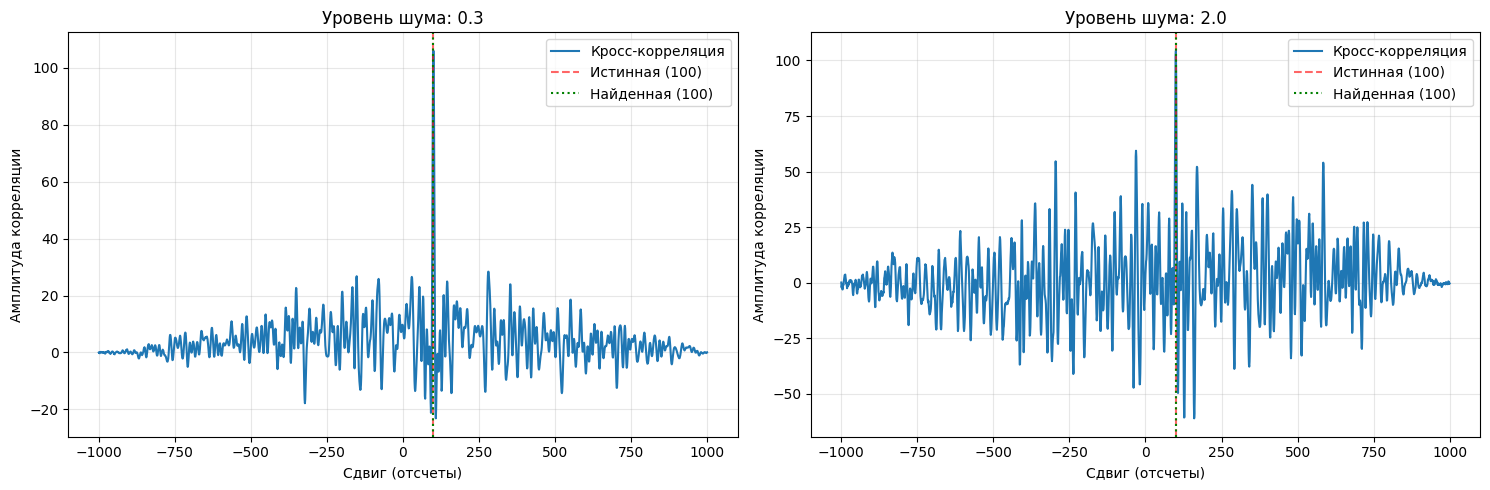

In [19]:
# 1. Генерация сложного сигнала x
fs = 1000
duration = 1.0
t = np.arange(0, duration, 1/fs)
n_signals = 100

x = np.zeros_like(t)
np.random.seed(42) # Для воспроизводимости

for _ in range(n_signals):
    freq = np.random.uniform(10, 100)
    amp = np.random.uniform(0.5, 1.5)
    phase = np.random.uniform(0, 2 * np.pi)
    x += amp * np.sin(2 * np.pi * freq * t + phase)

# Нормализация x в [-1, 1]
x = 2 * (x - np.min(x)) / (np.max(x) - np.min(x)) - 1

# 2. Создание зашумленного и сдвинутого сигнала y
true_delay = 100
# Сдвигаем сигнал (заполняем нулями начало)
y_clean = np.zeros_like(x)
y_clean[true_delay:] = x[:-true_delay]

def get_delay_estimate(signal_x, signal_y):
    corr = np.correlate(y_clean_with_noise, signal_x, mode='full')
    lags = np.arange(-len(signal_x) + 1, len(signal_x))
    delay_est = lags[np.argmax(corr)]
    return delay_est, corr, lags

# 3. Визуализация для разных уровней шума
noise_levels = [0.3, 2.0]
plt.figure(figsize=(15, 5))

for i, nl in enumerate(noise_levels):
    noise = nl * np.random.randn(len(x))
    y_noisy = y_clean + noise

    # Считаем корреляцию (используем y_noisy и x)
    corr = np.correlate(y_noisy, x, mode='full')
    lags = np.arange(-len(x) + 1, len(x))
    delay_est = lags[np.argmax(corr)]

    plt.subplot(1, 2, i+1)
    plt.plot(lags, corr, label='Кросс-корреляция')
    plt.axvline(true_delay, color='r', linestyle='--', alpha=0.6, label=f'Истинная ({true_delay})')
    plt.axvline(delay_est, color='g', linestyle=':', label=f'Найденная ({delay_est})')
    plt.title(f'Уровень шума: {nl}')
    plt.xlabel('Сдвиг (отсчеты)')
    plt.ylabel('Амплитуда корреляции')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Вопросы:**
- Как зависит точность оценки задержки от уровня шума? При каком уровне шума вычисленная задержка отличается от истинной более чем на 10%? При каком уровне шума вычисленная задержка становится практически неотличима от `0`?
- Почему при высоком уровне шума могут появляться ложные пики?

1. Метод кросс-корреляции чрезвычайно надежен благодаря своей способности «накапливать» полезный сигнал и усреднять некоррелированный шум. Порог ошибки в 10%: В моем случае (истинная задержка = 100 отсчетов) ошибка более чем на 10% означает отклонение найденного пика более чем на 10 отсчетов от центра. Судя по графику для шума 2.0, метод все еще безошибочно находит значение 100. Задержка неотличима от 0:При выбранных параметрах это произойдет только при экстремально высоких уровнях шума, когда полезный сигнал практически полностью подавлен.
2. На графике с уровнем шума 2.0 отчетливо видно, что помимо основного пика на 100 отсчетах появилось множество «зубьев» по бокам. Это происходит по следующим причинам: корреляция шума с шумом, частичное совпадение гармоник и снижение отношения сигнал/шум

## Задание 4. Обнаружение шаблона в зашумлённом сигнале

### Цель
Найти местоположение сигнала, имеющего форму гауссова импульса, модулированного синусоидой, в смеси с шумом. Исследовать влияние отношения сигнал/шум на точность обнаружения.

### Задание
1. Создайте шаблон `template` – произведение гауссовой огибающей (σ=100 отсчётов) на синусоиду частотой 20 Гц (при fs=1000 Гц). Длина шаблона примерно 6σ.
2. Создайте длинный сигнал `long_signal` длиной 2000 отсчётов, состоящий из:
   - случайного сигнала (шума), созданного с помощью `numpy.random.randn()` с единичной амплитудой,
   - вставленного в случайную позицию шаблона, умноженного на амплитуду `A` (например, 2).
3. Используйте кросс-корреляцию `np.correlate(long_signal, template, mode='valid')` для поиска позиции шаблона. Найдите индекс максимума корреляции.
4. Повторите эксперимент для разных отношений сигнал/шум (SNR), варьируя амплитуду шаблона от 0.2 до 5.
5. Для одного значения SNR (например, 1) визуализируйте: исходный длинный сигнал, шаблон, результат кросс-корреляции с отмеченным пиком.

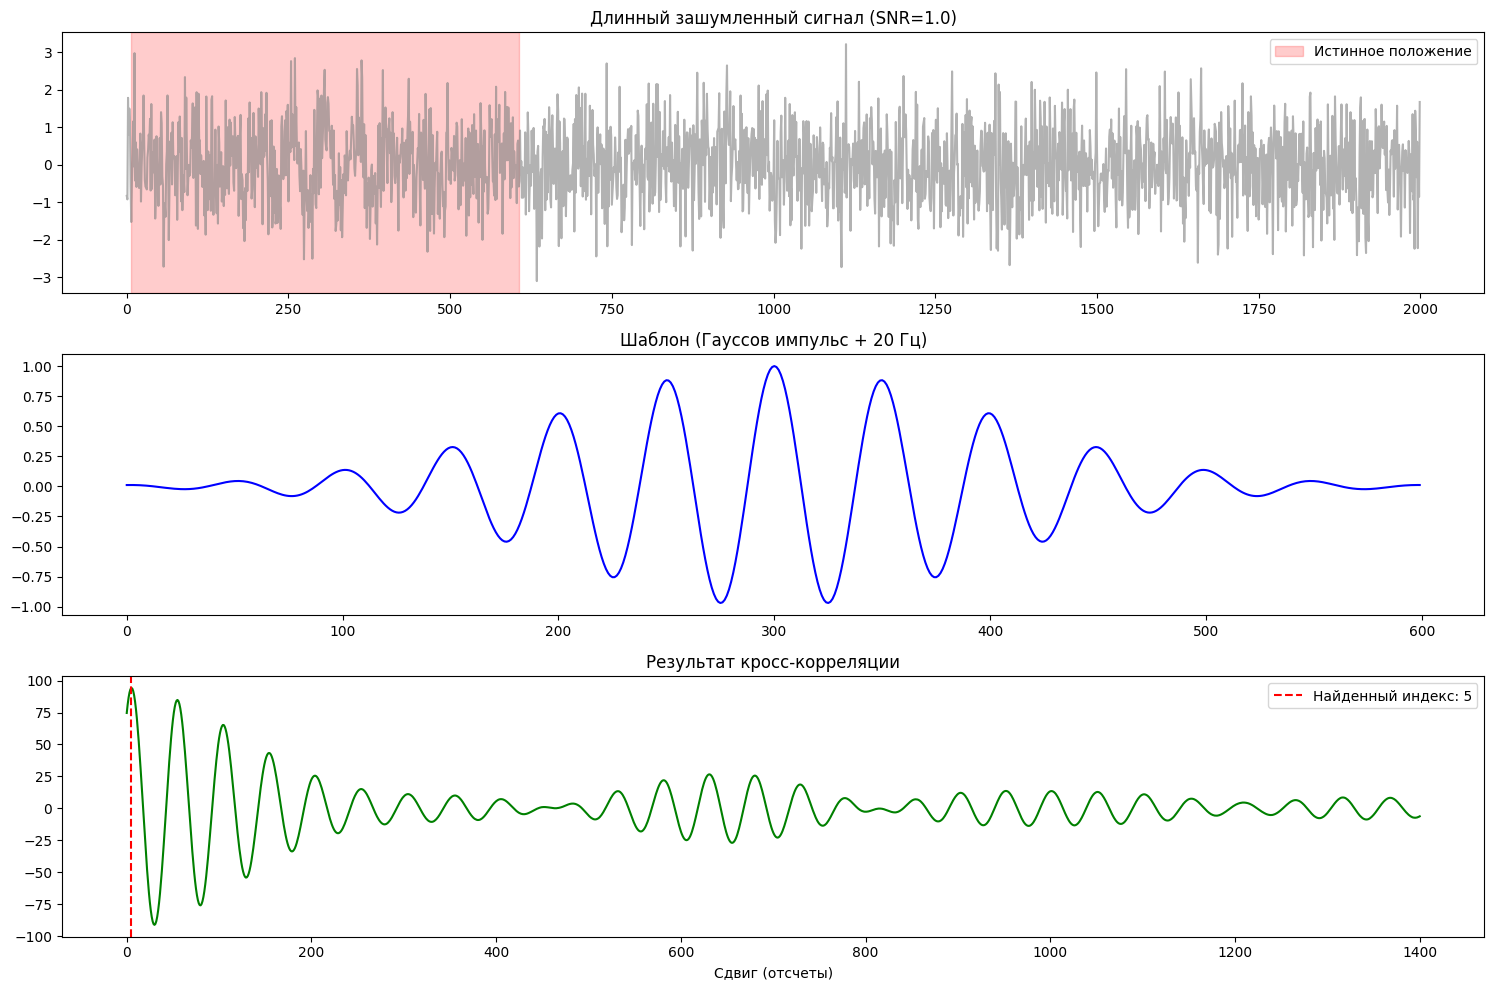

Истинная позиция: 6
Найденная позиция: 5
Ошибка: 1 отсчетов


In [26]:
# 1. Создание шаблона
fs = 1000
sigma = 100
t_template = np.arange(-3*sigma, 3*sigma)
template = np.exp(-t_template**2 / (2 * sigma**2)) * np.cos(2 * np.pi * 20 * t_template / fs)

# 2. Создание длинного сигнала с шумом
N_long = 2000
long_signal = np.random.randn(N_long) # Шум с единичной амплитудой
A = 1.0
true_pos = np.random.randint(0, N_long - len(template))

# Вставка шаблона
long_signal[true_pos : true_pos + len(template)] += A * template

# 3. Кросс-корреляция
corr = np.correlate(long_signal, template, mode='valid')
found_pos = np.argmax(corr)

# 4. Визуализация
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(long_signal, color='gray', alpha=0.6)
plt.title(f'Длинный зашумленный сигнал (SNR={A})')
plt.axvspan(true_pos, true_pos + len(template), color='red', alpha=0.2, label='Истинное положение')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(template, color='blue')
plt.title('Шаблон (Гауссов импульс + 20 Гц)')

plt.subplot(3, 1, 3)
plt.plot(corr, color='green')
plt.axvline(found_pos, color='r', linestyle='--', label=f'Найденный индекс: {found_pos}')
plt.title('Результат кросс-корреляции')
plt.xlabel('Сдвиг (отсчеты)')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Истинная позиция: {true_pos}")
print(f"Найденная позиция: {found_pos}")
print(f"Ошибка: {abs(true_pos - found_pos)} отсчетов")

**Вопросы:**
- При каком SNR результаты измерения резко ухудшаются?

при SNR < 0.5 результаты измерения резко ухудшаются

## Задание 5. Поиск фрагмента в реальном аудиосигнале

### Цель
Применить кросс-корреляцию для нахождения заданного фрагмента в аудиофайле. Фрагмент и основной файл предоставлены (студентам нужно будет загрузить их).

### Задание
1. Загрузите аудиофайл `full_audio.wav` и фрагмент `fragment.wav`. Используйте `scipy.io.wavfile.read`.
2. Вычислите кросс-корреляцию между полным сигналом и фрагментом.
3. Найдите позицию максимального значения корреляции и определите временное смещение (в отсчётах и в секундах).
4. Постройте график кросс-корреляции и отметьте найденный пик.
5. Вырежьте из полного сигнала участок, соответствующий найденной позиции, и прослушайте его (используйте `Audio`). Убедитесь, что он совпадает с фрагментом.

In [28]:
# Загружаем файл и сохраняем под именем audio.wav
!wget -O full_audio.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/full_audio.wav"
!wget -O fragment.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/fragment.wav"

--2026-04-12 11:12:42--  https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/full_audio.wav
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/full_audio.wav [following]
--2026-04-12 11:12:43--  https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/full_audio.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6990446 (6.7M) [audio/wav]
Saving to: ‘full_audio.wav’

full_audio.wav      100%[===================>]   6.67M  --.-KB/s    in 0.02s   

2026-04-12 11:12:43 (344 MB/s) - ‘full_audio.wav’ saved [6990446/69

/tmp/ipykernel_1074/4193491627.py:1: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, full_audio = wavfile.read('full_audio.wav')
/tmp/ipykernel_1074/4193491627.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_f, fragment = wavfile.read('fragment.wav')


Фрагмент найден на отсчете: 279235
Временная метка: 6.332 сек.


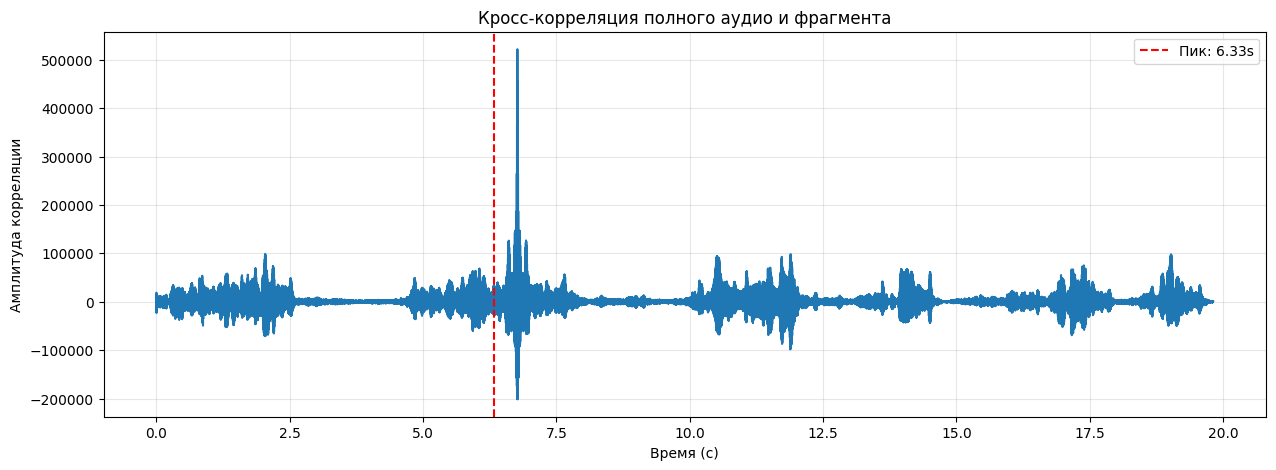

Прослушайте найденный фрагмент:


In [31]:

fs, full_audio = wavfile.read('full_audio.wav')
fs_f, fragment = wavfile.read('fragment.wav')

if len(full_audio.shape) > 1:
    full_audio = full_audio[:, 0]
if len(fragment.shape) > 1:
    fragment = fragment[:, 0]



from scipy.signal import correlate
corr = correlate(full_audio, fragment, mode='valid', method='fft')

# 3. Поиск позиции
found_index = np.argmax(corr)
found_time_sec = found_index / fs

print(f"Фрагмент найден на отсчете: {found_index}")
print(f"Временная метка: {found_time_sec:.3f} сек.")

# 4. Визуализация
plt.figure(figsize=(15, 5))
plt.plot(np.linspace(0, len(full_audio)/fs, len(corr)), corr)
plt.axvline(found_time_sec, color='r', linestyle='--', label=f'Пик: {found_time_sec:.2f}s')
plt.title('Кросс-корреляция полного аудио и фрагмента')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда корреляции')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Прослушивание результата
extracted_segment = full_audio[found_index : found_index + len(fragment)]

print("Прослушайте найденный фрагмент:")
display(Audio(extracted_segment, rate=fs))


**Вопросы:**
- Почему перед вычислением корреляции сигналы следует нормализовать?
- Сколько раз в сигнале встречается вырезанное во фрагменте слово? Удаётся ли с помощью корреляционного анализа определить его во всех случаях? Возникают ли ложные максимумы?
- Что будет, если фрагмент не содержится в полном сигнале? Как это отразится на корреляции?

1. Нормировка нужна, чтобы исключить влияние громкости: Мы ищем сходство формы сигнала, а не его мощности. Без нормализации громкий шум может быть ошибочно принят за тихий полезный сигнал.
2. Один раз, примерно на 6.3 с. Сильных ложных максимумов нет
3. Если искомый фрагмент отсутствует, график корреляции будет выглядеть как однородный шум без ярко выраженных всплесков.